# Ejercicio 1: Estadística Descriptiva y Análisis Univariado

Realice un análisis estadístico descriptivo completo de la base de datos.

**Tareas a realizar:**
- Cargue el dataset y examine su estructura básica (dimensiones, tipos de datos, valores faltantes). Para la carga de la base de datos, utilice el comando:
`datos_penguins = sns.load_dataset('penguins')`
Considere los comandos `shape`, `info` y `isnull().sum()` de la librería pandas para explorar la estructura y los valores faltantes.
- Calcule las estadísticas descriptivas fundamentales (media, mediana, moda, desviación estándar, cuartiles) para las variables numéricas. Considere los comandos describe, median y mode de pandas para obtener estos valores de forma directa.
- Calcule estadísticas de orden superior (asimetría y curtosis) e interprete su significado en el contexto del problema. Considere los comandos skew y kurtosis del módulo stats de la librería scipy, aplicados a las series numéricas. - - -
- Genere histogramas para las variables numéricas, evaluando la forma de sus
distribuciones. Considere los comandos hist de pandas y matplotlib, así como
histplot del módulo seaborn.
- Construya boxplots para identificar valores atípicos en las variables numéricas. Considere el comando boxplot de matplotlib o seaborn.
- Identifique la distribución de las variables categóricas mediante tablas de frecuencia. Considere el comando value_counts de pandas para obtener la frecuencia absoluta
de cada categoría.

Genere un reporte descriptivo que caracterice completamente la distribución univariada de cada
variable, identificando patrones, anomalías y características relevantes para análisis posteriores.

# 1.1 Estructura basica del dataset.

In [6]:
import pandas as pd
import seaborn as sns

def eda_resumen(df: pd.DataFrame, top_n=5):
  """Genera un resumen exploratorio (EDA) de un DataFrame.

  Calcula para cada columna data type, cantidad y porcentaje de
  valores nulos, y cantidad de valores unicos. Ademas devuelve
  estadisticos descriptivos generales.

  Args:
    df: DataFrame a analizar.
    top_n: Cantidad de filas a mostrar en la vista previa (head).
  """
  print(f"Dimensiones (filas, columnas): {df.shape}")
  info = pd.DataFrame({
      "dtype": df.dtypes,
      "n_nulos": df.isna().sum(),
      "porcentaje_nulos": df.isna().mean().round(3),
      "n_unicos": df.nunique(),
      "moda":  df.mode().iloc[0]
  })

  return info.sort_index(), df.head(top_n), df.describe(include="all").T

pinguinos = sns.load_dataset("penguins")
info, cabeza, descriptivos = eda_resumen(pinguinos)
print(info)

Dimensiones (filas, columnas): (344, 7)
                     dtype  n_nulos  porcentaje_nulos  n_unicos    moda
bill_depth_mm      float64        2             0.006        80    17.0
bill_length_mm     float64        2             0.006       164    41.1
body_mass_g        float64        2             0.006        94  3800.0
flipper_length_mm  float64        2             0.006        55   190.0
island                 str        0             0.000         3  Biscoe
sex                    str       11             0.032         2    Male
species                str        0             0.000         3  Adelie


El dataset tiene 344 observaciones y 7 columnas (3 categóricas:
`species`, `island`, `sex`; 4 numéricas: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`). Hay valores faltantes acotados: 2 filas con las cuatro medidas numéricas ausentes simultáneamente (probablemente el mismo registro incompleto) y 11 filas sin dato de `sex`. Al ser pocos casos sobre el total, se pueden excluir con `dropna()` para los análisis que lo requieran sin perder representatividad.


In [7]:
cabeza

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


# 1.2 Estadisticas descriptivas

In [8]:
# estadisticas descriptivas para las numericas
# .describe() ya trabaja por default con columnas numericas
# pinguinos.describe()
import numpy as np

numericas = pinguinos.select_dtypes(include=[np.number])
resumen = numericas.agg(["count", "mean", "median", "std", "min", "max"]).T
resumen["IQR"] = numericas.quantile(0.75) - numericas.quantile(0.25)
print(resumen.round(2))

                   count     mean   median     std     min     max      IQR
bill_length_mm     342.0    43.92    44.45    5.46    32.1    59.6     9.27
bill_depth_mm      342.0    17.15    17.30    1.97    13.1    21.5     3.10
flipper_length_mm  342.0   200.92   197.00   14.06   172.0   231.0    23.00
body_mass_g        342.0  4201.75  4050.00  801.95  2700.0  6300.0  1200.00


In [9]:
numericas.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


Las cuatro variables numéricas tienen escalas muy distintas (`bill_depth_mm` ronda los 17 mm mientras `body_mass_g` ronda los 4200 g), por lo que cualquier comparación directa de dispersión entre ellas requiere normalizar. La media y la mediana están cercanas entre sí en las cuatro variables, lo que sugiere ausencia de asimetría extrema.


# 1.3 Estadisticos de orden superior: asimetria y curtosis

In [10]:
from scipy import stats

# asimetria = {}
# curtosis = {}

# for col in numericas.columns:
#     datos = numericas[col].dropna()
#     asimetria[col] = stats.skew(datos)
#     curtosis[col] = stats.kurtosis(datos)


asimetria = numericas.apply(lambda col: stats.skew(col.dropna()))
curtosis = numericas.apply(lambda col: stats.kurtosis(col.dropna()))

resultados = pd.DataFrame({"asimetria": asimetria, "curtosis": curtosis})
print(resultados)

                   asimetria  curtosis
bill_length_mm      0.052885 -0.880765
bill_depth_mm      -0.142835 -0.911155
flipper_length_mm   0.344164 -0.987434
body_mass_g         0.468264 -0.726243


Explicacion: ** llenar **

# 1.4 Histogramas

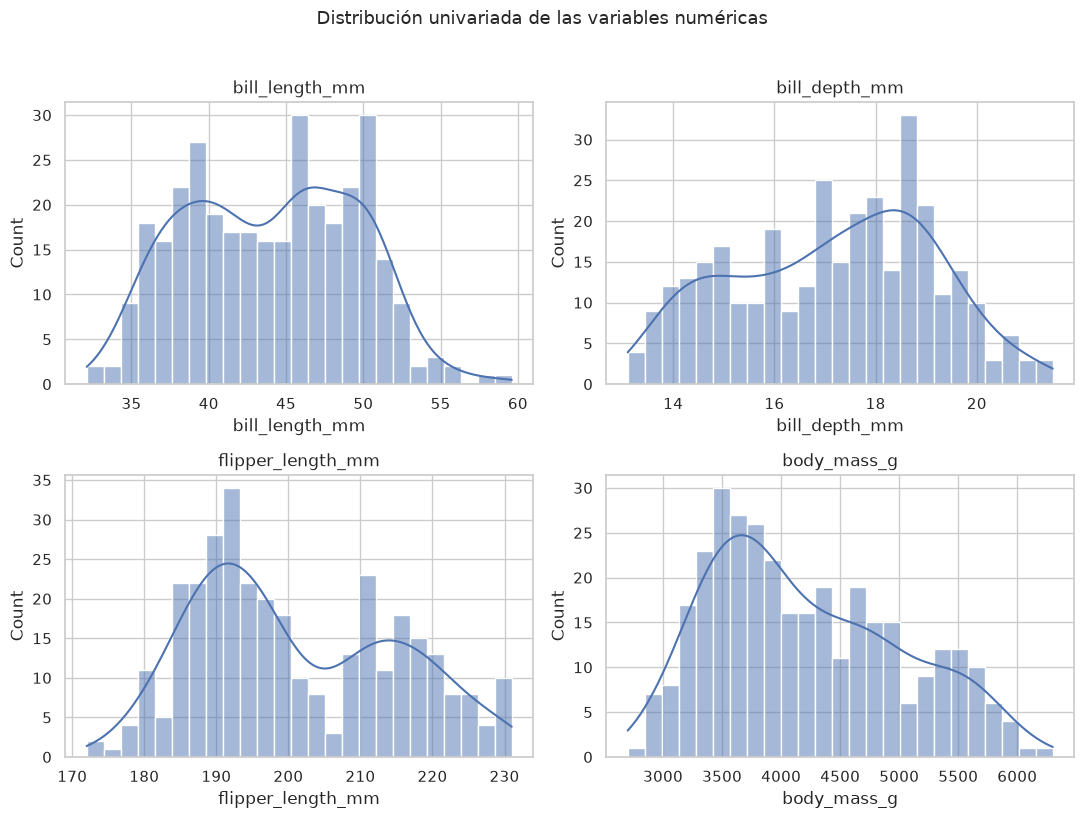

In [11]:
# Nota de maxip: aca hay que tener cuidado, porque las visualizaciones ellos toman
# de que sean lindos tambien los graficos pero hay que estar piyos para explicar.

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

pinguinos = sns.load_dataset("penguins").dropna()
numericas = pinguinos.select_dtypes(include="number")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), numericas):
    sns.histplot(pinguinos[col], bins=25, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
fig.suptitle("Distribución univariada de las variables numéricas", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


`bill_length_mm` y `body_mass_g` muestran una forma bimodal / multimodal, señal de que mezclan especies con tamaños distintos. `bill_depth_mm` y `flipper_length_mm` también insinúan dos grupos. Esto anticipa que la variable `species` va a ser un fuerte factor explicativo de estas distribuciones.

# 1.5 - Boxplots

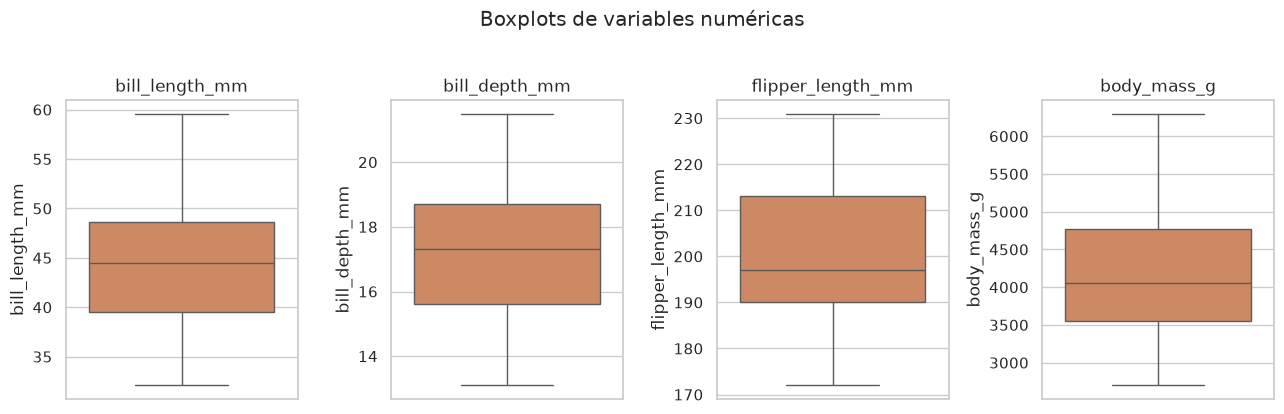

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

pinguinos = sns.load_dataset("penguins").dropna()
numericas = pinguinos.select_dtypes(include="number")

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, col in zip(axes, numericas):
    sns.boxplot(y=pinguinos[col], ax=ax, color="#DD8452")
    ax.set_title(col)
fig.suptitle("Boxplots de variables numéricas", y=1.03)
fig.tight_layout()
plt.show()


Ninguna variable numérica presenta una cantidad relevante de outliers según el
criterio del IQR, el cual es un resultado esperable dada la curtosis negativa/cercana a 0 observada antes. El dataset no muestra errores de carga evidentes ni valores extremos que requieran tratamiento especial.

In [13]:
categoricas = pinguinos.select_dtypes(include="object")

for col in categoricas.columns:
    print(f"Frecuencia de {col}:")
    tabla = pd.DataFrame({
        "n": pinguinos[col].value_counts(),
        "%": (pinguinos[col].value_counts(normalize=True) * 100).round(1)
    })
    print(tabla)
    print()

Frecuencia de species:
             n     %
species             
Adelie     146  43.8
Gentoo     119  35.7
Chinstrap   68  20.4

Frecuencia de island:
             n     %
island              
Biscoe     163  48.9
Dream      123  36.9
Torgersen   47  14.1

Frecuencia de sex:
          n     %
sex              
Male    168  50.5
Female  165  49.5



/tmp/ipykernel_22880/1965475303.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = pinguinos.select_dtypes(include="object")


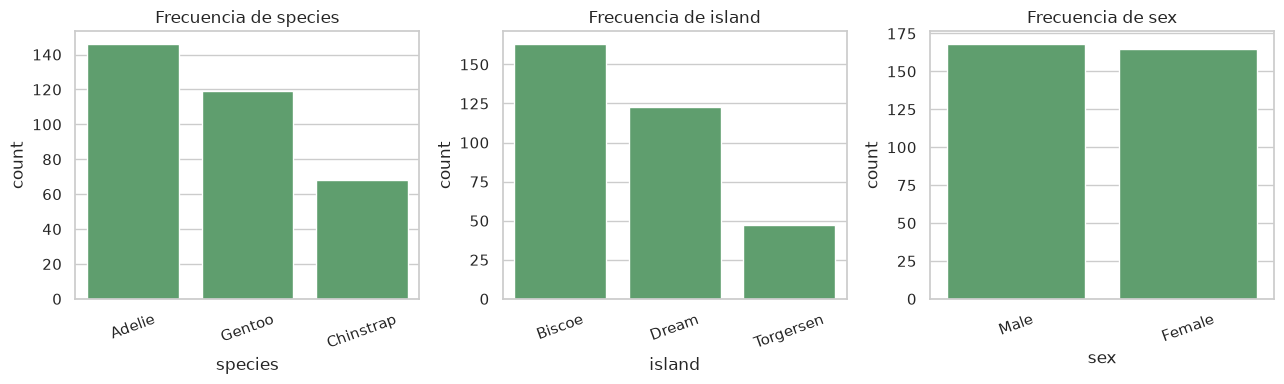

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, categoricas):
    orden = pinguinos[col].value_counts().index
    sns.countplot(x=pinguinos[col], order=orden, ax=ax, color="#55A868")
    ax.set_title(f"Frecuencia de {col}")
    ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

`species` está moderadamente desbalanceada (Adelie es la más numerosa, Chinstrap la menos), lo mismo que `island` (Biscoe concentra la mayoría de los registros, en gran parte por ser la única isla donde habita Gentoo). `sex` está prácticamente balanceada entre machos y hembras, salvo los 11 valores faltantes ya señalados.


# Ejercicio 2: Análisis Bivariado - Correlaciones y Asociaciones 
Explore las relaciones entre pares de variables utilizando técnicas de análisis bivariado. Tareas a realizar: 
- Calcule la matriz de correlación para todas las variables numéricas y visualícela mediante un heatmap. Considere el comando `corr` de pandas para calcular la matriz. Para la visualización, utilice `heatmap` de seaborn o `DataFrame.plot.imshow` de pandas. 
- Genere scatter plots para las relaciones más significativas, incorporando líneas de tendencia. Considere el comando `scatterplot` de seaborn o `matplotlib.pyplot.scatter` para graficar puntos. Para incluir líneas de tendencia, utilice lmplot de seaborn. 
- Identifique correlaciones espurias y evalúe la significancia estadística de las asociaciones encontradas. Considere el comando `corr` de pandas o `corrcoef` de 
numpy para calcular coeficientes, y utilice las funciones pearsonr o spearmanr del módulo stats de scipy para obtener el valor del coeficiente y su significancia (valor p). 
- Analice la relación entre "bill_length_mm" y "bill_depth_mm" segmentada por especie utilizando gráficos de dispersión con codificación por color. Considere el comando scatterplot de seaborn. Si se desea añadir una línea de tendencia, puede emplear `lmplot` de seaborn.
- Construya tablas de contingencia para examinar la asociación entre variables categóricas. Considere el comando crosstab de pandas para generar tablas de doble 
entrada entre variables categóricas. 
- Aplique pruebas de independencia chi-cuadrado para variables categóricas. Considere el comando chi2_contingency del módulo stats de scipy, aplicado a las tablas 
generadas con crosstab de pandas o contingency.crosstab de scipy.stats. 

Genere un reporte que incluya una caracterización completa de las relaciones bivariadas que 
permita identificar variables predictoras potenciales y patrones de dependencia entre 
características de las propiedades.  

### 2.1 Matriz de correlación y heatmap

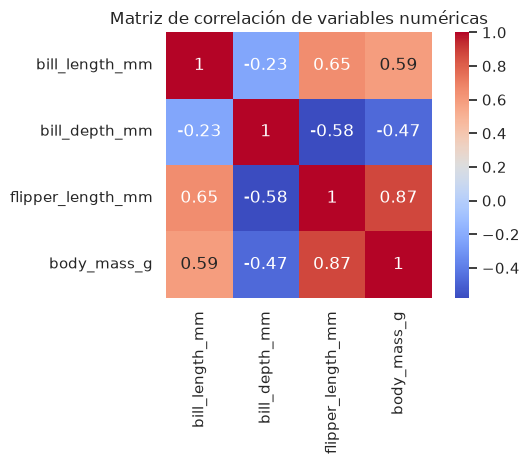

In [18]:
matriz_corr = pinguinos.select_dtypes(include="number").corr()

sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", square=True)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()


**Lectura:** `flipper_length_mm` y `body_mass_g` están fuertemente correlacionadas(r cercano a uno):
pingüinos con aletas más largas tienden a pesar más, lo cual es biológicamente esperable (aves de
mayor porte). `bill_depth_mm` correlaciona negativamente con las demás variables.

Es importante recordar que correlacion no implica causalidad; esta correlación negativa podría ser espuria, producto de mezclar especies con formas
de pico distintas (paradoja de Simpson), por lo que se revisará luego

**Paradoja de Simpson**: Es un fenómeno estadístico donde una tendencia que aparece en varios grupos de datos por separado se invierte o desaparece cuando juntás esos grupos en uno solo.


### 2.2 Scatter plots con línea de tendencia para las relaciones más significativas

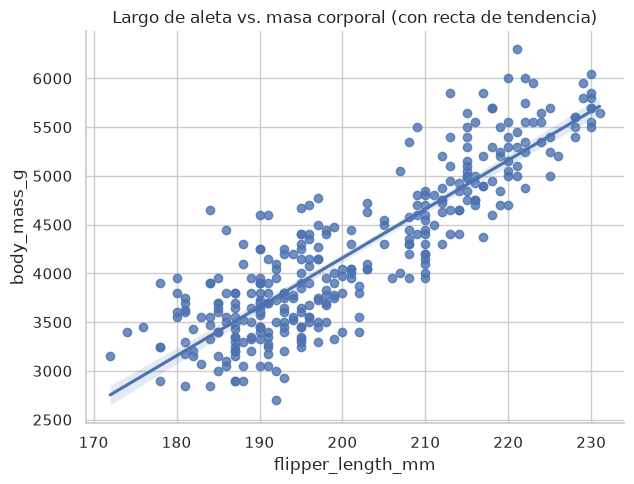

In [26]:
sns.lmplot(data=pinguinos,
           x="flipper_length_mm", y="body_mass_g",
           height=5, aspect=1.3) # width = height * aspect
plt.title("Largo de aleta vs. masa corporal (con recta de tendencia)")
plt.tight_layout()
plt.show()

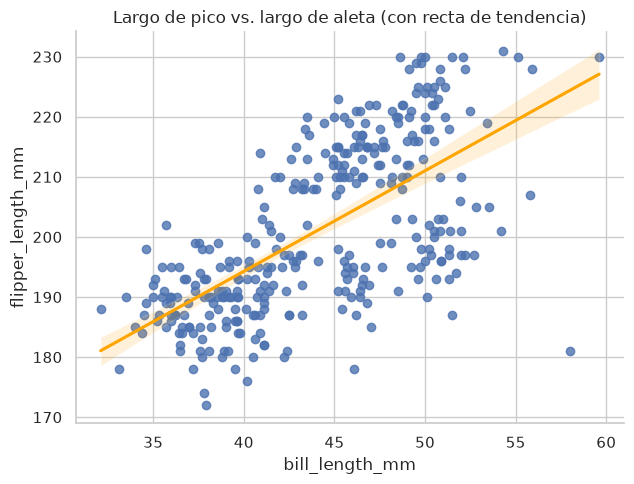

In [27]:
sns.lmplot(data=pinguinos, 
           x="bill_length_mm", y="flipper_length_mm",
           height=5, aspect=1.3, line_kws={"color": "orange"})
plt.title("Largo de pico vs. largo de aleta (con recta de tendencia)")
plt.tight_layout()
plt.show()

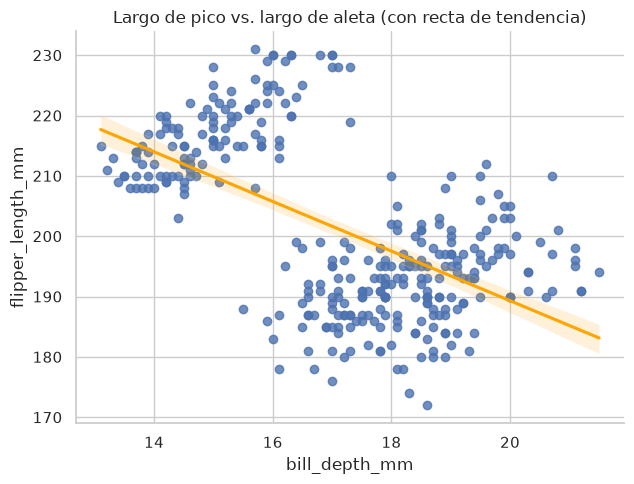

In [28]:
sns.lmplot(data=pinguinos, 
           x="bill_depth_mm", y="flipper_length_mm",
           height=5, aspect=1.3, line_kws={"color": "orange"})
plt.title("Largo de pico vs. largo de aleta (con recta de tendencia)")
plt.tight_layout()
plt.show()

### 2.3 Significancia estadística de las asociaciones

In [ ]:
# TODO: hacer las otras (MaxiZ)
from scipy.stats import pearsonr, spearmanr

# significancia -> alpha = 0.05
# H0) No existe correlacion lineal entre las dos variables
# H1) noH0)

r, p_valor = pearsonr(pinguinos["flipper_length_mm"], pinguinos["body_mass_g"])
r_spearman, p_valor_spearman = spearmanr(pinguinos["flipper_length_mm"], pinguinos["body_mass_g"])
print(f"r = {r:.3f}, p = {p_valor}")
print(f"r = {r_spearman:.3f}, p = {p_valor_spearman}")

r = 0.873, p = 3.1328362509712445e-105
r = 0.840, p = 4.630423990534309e-90


Pearson mide qué tan bien se ajustan los datos a una relación lineal específica.

Spearman primero convierte cada variable en rangos y después calcula la correlación de Pearson sobre esos rangos. Solo le importa si la correlacion es monótona (que cuando una variable sube, la otra consistentemente sube o consistentemente baja, sin importar a qué ritmo).

**Conclusiones**:
- Tamanio de la aleta vs Peso corporal: como p_valor < alpha, rechazamos H0) y concluimos que hay evidencia significativa para decir que estan correlacionadas.

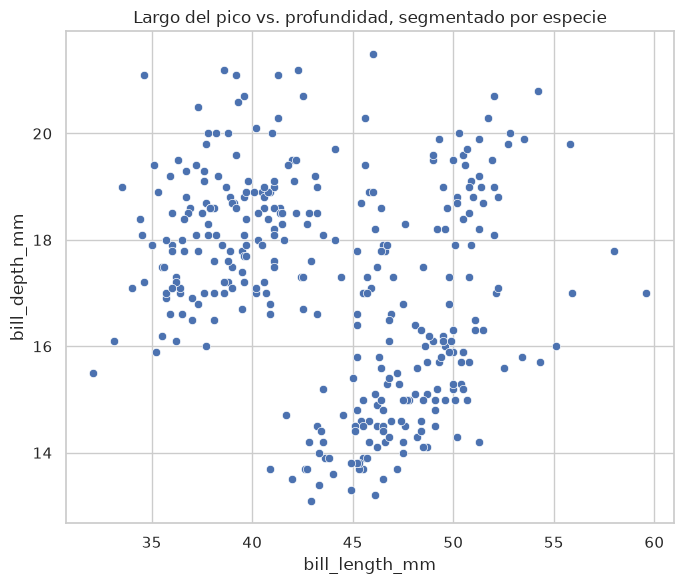

In [48]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=pinguinos, x="bill_length_mm", y="bill_depth_mm")
plt.title("Largo del pico vs. profundidad, segmentado por especie")
plt.tight_layout()
plt.show()

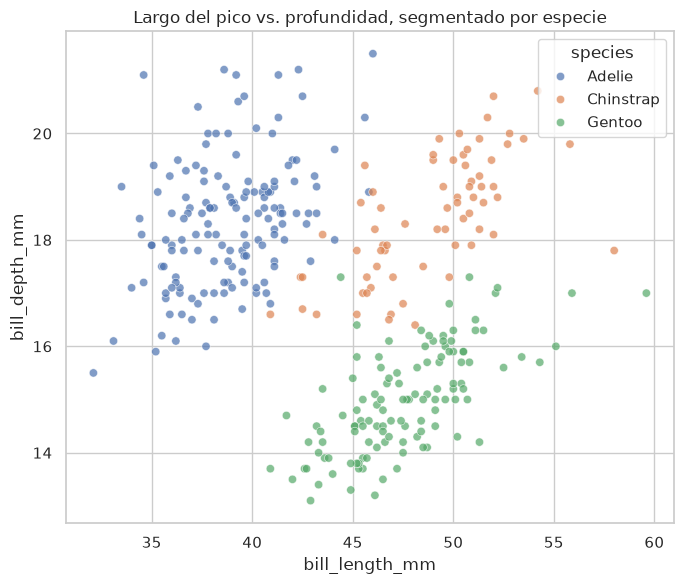

In [51]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=pinguinos, x="bill_length_mm", y="bill_depth_mm", 
                hue="species", alpha=0.7)
plt.title("Largo del pico vs. profundidad, segmentado por especie")
plt.tight_layout()
plt.show()

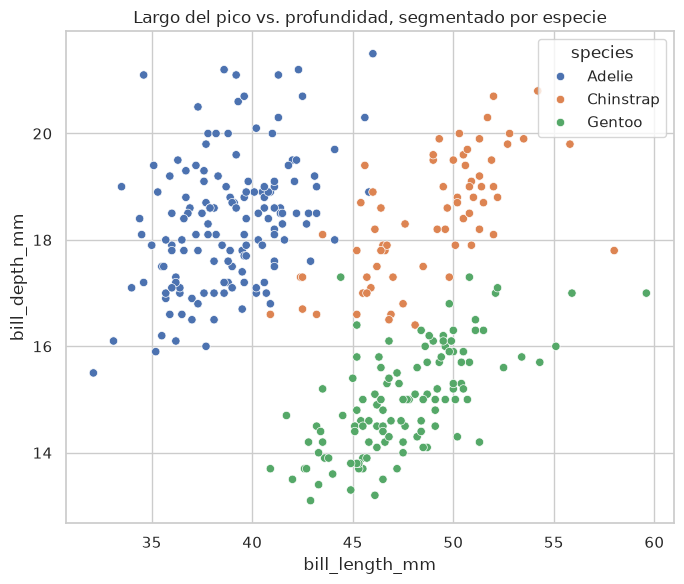

In [52]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=pinguinos, x="bill_length_mm", y="bill_depth_mm", 
                hue="species")
plt.title("Largo del pico vs. profundidad, segmentado por especie")
plt.tight_layout()
plt.show()

In [ ]:
r_global = pinguinos["bill_length_mm"].corr(pinguinos["bill_depth_mm"])
print(f"Correlacion global (sin segmentar): {r_global:.3f}\n")

for esp, sub in pinguinos.groupby("species", observed=True):
    r = sub["bill_length_mm"].corr(sub["bill_depth_mm"])
    print(f"Correlación dentro de {esp}: {r:.3f}")

Correlación global (sin segmentar): -0.229

Correlación dentro de Adelie: 0.386
Correlación dentro de Chinstrap: 0.654
Correlación dentro de Gentoo: 0.654


**Es la paradoja de Simpson en acción:** sin distinguir especie, `bill_length_mm` y `bill_depth_mm`
muestran correlación global negativa. Pero al segmentar por especie, la correlación
**dentro** de cada especie es positiva. Esto confirma que la correlación negativa global es
**espuria**: no refleja una relación biológica real entre largo y profundidad del pico, sino un
artefacto de que las tres especies ocupan regiones distintas del plano. `species` es la variable de
confusión (*confounder*) que explica el cambio de signo.